In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [112]:
# parquet dosyalarını sıralı şekilde alıyorum
files = sorted(glob.glob("../data/*.parquet"))
print(files)

['../data/yellow_tripdata_2015-01.parquet', '../data/yellow_tripdata_2015-02.parquet', '../data/yellow_tripdata_2015-03.parquet', '../data/yellow_tripdata_2015-04.parquet', '../data/yellow_tripdata_2015-05.parquet', '../data/yellow_tripdata_2015-06.parquet', '../data/yellow_tripdata_2015-07.parquet', '../data/yellow_tripdata_2015-08.parquet', '../data/yellow_tripdata_2015-09.parquet', '../data/yellow_tripdata_2015-10.parquet', '../data/yellow_tripdata_2015-11.parquet', '../data/yellow_tripdata_2015-12.parquet']


In [113]:
# İlk olarak sadece Ocak ayı verisini inceliyorum
df_january = pd.read_parquet("../data/yellow_tripdata_2015-01.parquet")
df_january.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None


# Veriye genel bakış


In [114]:
# satır ve sütun sayısının kontrol edilmesi
df_january.shape

(12741035, 19)

In [115]:
# sütun isimlerini kontrol ediyorum
df_january.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [116]:
# veri tiplerinin kontrol edilmesi
df_january.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge             object
airport_fee                      object
dtype: object

In [117]:
# Eksik değerleri kontrol ediyorum
df_january.isnull().sum()

VendorID                        0
tpep_pickup_datetime            0
tpep_dropoff_datetime           0
passenger_count                 0
trip_distance                   0
RatecodeID                      0
store_and_fwd_flag              0
PULocationID                    0
DOLocationID                    0
payment_type                    0
fare_amount                     0
extra                           0
mta_tax                         0
tip_amount                      0
tolls_amount                    0
improvement_surcharge           3
total_amount                    0
congestion_surcharge     12741035
airport_fee              12741035
dtype: int64

In [118]:
# pickup sütununu datetime türüne dönüştürüyorum
df_january["tpep_pickup_datetime"] = pd.to_datetime(
    df_january["tpep_pickup_datetime"],
    errors="coerce")
# Ocak ayı için saatlik trip sayısını hesaplıyorum
january_hourly = (
    df_january.set_index("tpep_pickup_datetime")
    .resample("h")
    .size()
    .reset_index(name="trip_count"))
january_hourly.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,28312
1,2015-01-01 01:00:00,31707
2,2015-01-01 02:00:00,28068
3,2015-01-01 03:00:00,24288
4,2015-01-01 04:00:00,17081


### Aylık dosyaların eklenmesi


In [119]:
# İlk 6 ay için gerekli sütunları okuyorum
all_data = []

for file in files[:6]:

    print("Reading:", file)

    temp_df = pd.read_parquet(
        file,
        columns=[
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "passenger_count",
            "trip_distance",
            "RatecodeID",
            "payment_type",
            "fare_amount",
            "extra",
            "mta_tax",
            "tip_amount",
            "tolls_amount",
            "total_amount",
            "improvement_surcharge",
            "airport_fee",
            "congestion_surcharge"
        ])
    all_data.append(temp_df)
# ilk 6 ayı tek dataframe içinde birleştiriyorum
df = pd.concat(all_data, ignore_index=True)

print("Dataset shape:", df.shape)

Reading: ../data/yellow_tripdata_2015-01.parquet
Reading: ../data/yellow_tripdata_2015-02.parquet
Reading: ../data/yellow_tripdata_2015-03.parquet
Reading: ../data/yellow_tripdata_2015-04.parquet
Reading: ../data/yellow_tripdata_2015-05.parquet
Reading: ../data/yellow_tripdata_2015-06.parquet
Dataset shape: (77072751, 15)


In [120]:
# Sayısal sütunların temel istatistiklerini inceliyorum
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,improvement_surcharge
count,77072751,77072751,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07,7.707275e+07
mean,2015-04-01 06:30:35.084935,2015-04-01 06:55:19.993336,1.677936e+00,1.641442e+01,1.039064e+00,1.378112e+00,1.272111e+01,3.144517e-01,4.977200e-01,1.728755e+00,2.892661e-01,1.586908e+01,2.970713e-01
min,2015-01-01 00:00:00,1973-05-09 09:17:59,0.000000e+00,-4.084012e+07,1.000000e+00,1.000000e+00,-4.960000e+02,-7.900000e+01,-5.000000e-01,-1.180000e+02,-9.400000e+01,-4.963000e+02,-3.000000e-01
25%,2015-02-15 21:01:52,2015-02-15 21:15:06.500000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,8.380000e+00,3.000000e-01
50%,2015-04-01 00:45:29,2015-04-01 01:01:30,1.000000e+00,1.700000e+00,1.000000e+00,1.000000e+00,9.500000e+00,0.000000e+00,5.000000e-01,1.150000e+00,0.000000e+00,1.180000e+01,3.000000e-01
75%,2015-05-15 07:33:11,2015-05-15 07:47:30,2.000000e+00,3.180000e+00,1.000000e+00,2.000000e+00,1.450000e+01,5.000000e-01,5.000000e-01,2.260000e+00,0.000000e+00,1.775000e+01,3.000000e-01
max,2015-06-30 23:59:59,2253-08-23 07:56:38,9.000000e+00,5.901661e+07,9.900000e+01,5.000000e+00,5.033255e+05,6.524200e+02,8.080000e+01,3.950589e+06,1.450090e+03,3.950612e+06,7.000000e-01
std,NaN,NaN,1.335309e+00,1.411705e+04,6.041210e-01,4.981493e-01,8.723489e+01,4.636048e-01,4.662914e-02,4.500058e+02,1.551062e+00,4.687409e+02,2.995009e-02


In [121]:
# sayısal sütunların min, max, mean ve median değerlerini kontrol ediyorum
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "tolls_amount",
    "total_amount",
]
for col in numeric_columns:

    print("\nColumn:", col)

    print("Minimum:", df[col].min())

    print("Maximum:", df[col].max())

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())


Column: passenger_count
Minimum: 0
Maximum: 9
Mean: 1.6779355520863657
Median: 1.0

Column: trip_distance
Minimum: -40840124.4
Maximum: 59016609.3
Mean: 16.41441570289868
Median: 1.7

Column: fare_amount
Minimum: -496.0
Maximum: 503325.53
Mean: 12.721113349645453
Median: 9.5

Column: tip_amount
Minimum: -118.0
Maximum: 3950588.8
Mean: 1.7287553704940413
Median: 1.15

Column: tolls_amount
Minimum: -94.0
Maximum: 1450.09
Mean: 0.2892661377819509
Median: 0.0

Column: total_amount
Minimum: -496.3
Maximum: 3950611.6
Mean: 15.869080094468147
Median: 11.8


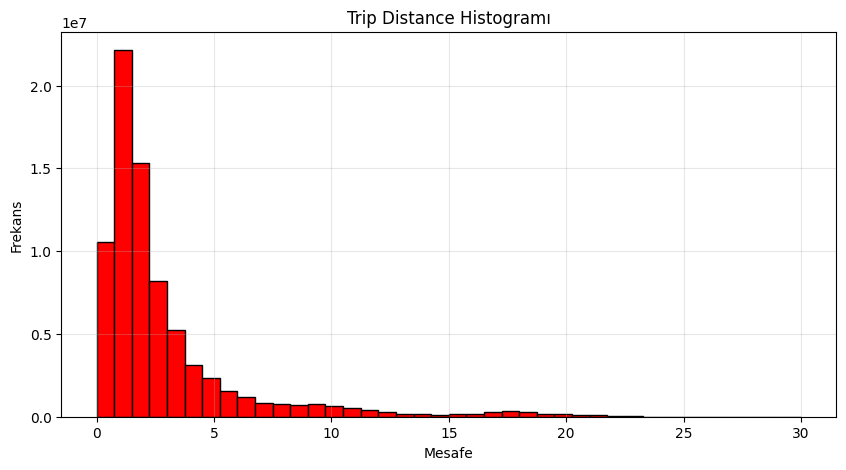

In [122]:

# veri temizliği öncesi histogram 
plt.figure(figsize=(10,5))

plt.hist(
    df["trip_distance"],
    bins=40,
    range=(0, 30),
    edgecolor="black",
    color ="red")
plt.title("Trip Distance Histogramı")
plt.xlabel("Mesafe")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()

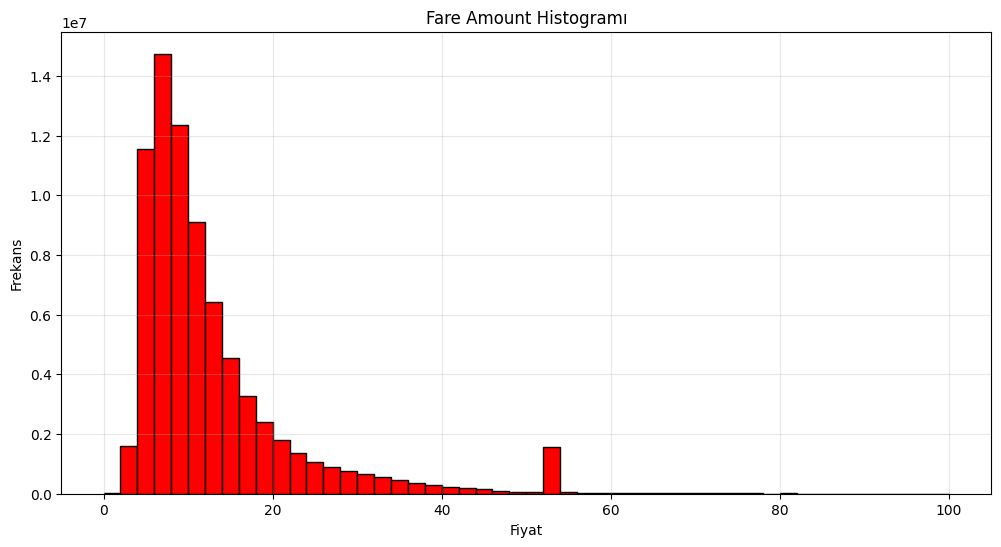

In [123]:
# fare amount temizliği öncesi histogram
plt.figure(figsize=(12,6))

plt.hist(
    df["fare_amount"],
    bins=50,
    range=(0,100),
    edgecolor="black",
    color ="red"
)
plt.title("Fare Amount Histogramı")
plt.xlabel("Fiyat")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()

In [124]:
# # negatif ve mantıksız değerleri kontrol ettikten sonra outlier temizleme işlemlerinde IQR yöntemini kullandım
print("Passenger count <= 0:", (df["passenger_count"] <= 0).sum())

print("Trip distance <= 0:", (df["trip_distance"] <= 0).sum())

print("Fare amount <= 0:", (df["fare_amount"] <= 0).sum())

print("Negative tip amounts:", (df["tip_amount"] < 0).sum())



Passenger count <= 0: 36366
Trip distance <= 0: 458002
Fare amount <= 0: 43487
Negative tip amounts: 488


# veride çok fazla aykırı değer bulunduğu için outlier temizleme işleminde IQR yöntemini kullanıyorum

In [125]:
# IQR için kontrol edilecek sayısal sütunlar: tolls amaount ve passenger count çıkarıldı. 
# tolss amaountta lower ve upper 0 gözüktü datasette çoğu yolculuk toll road kullanmadığı için kaldırdım. 
# passenger count'u ise lower boundda -4 değeri ve upper bounnda 7 değeri çıktı ben zaten bunu <= 5 olarak sınırlandırmıştım.
iqr_columns = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
]
iqr_bounds = {}
for col in iqr_columns:
    # Q1 ve Q3 değerlerini hesaplıyorum
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
   
    IQR = Q3 - Q1

    # daha esnek sınırlar için 1.5 yerine 5* kullandım
    lower_bound = Q1 - 5 * IQR
    upper_bound = Q3 + 5 * IQR

    # alt ve üst sınırları kaydedilmesi
    iqr_bounds[col] = (
        lower_bound,
        upper_bound)
    print(col)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print()

trip_distance
Lower bound: -9.9
Upper bound: 14.08

fare_amount
Lower bound: -33.5
Upper bound: 54.5

tip_amount
Lower bound: -11.299999999999999
Upper bound: 13.559999999999999

total_amount
Lower bound: -38.46999999999999
Upper bound: 64.6



In [126]:
# IQR sınırlarına göre temizleme koşullarını oluşturuyorum
condition = (
    (df["passenger_count"] > 0) &
    (df["passenger_count"] <= 5) &
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["tip_amount"] >= 0) &
    (df["total_amount"] > 0)
)

for col in iqr_columns:

    lower_bound, upper_bound = iqr_bounds[col]

    condition = condition & (
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    )

df_clean = df.loc[condition].copy()

print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (77072751, 15)
After cleaning: (71637943, 15)


In [127]:
# # pickup datetime sütununu datetime formatına dönüştürülmesi
df_clean["tpep_pickup_datetime"] = pd.to_datetime(
    df_clean["tpep_pickup_datetime"],
    errors="coerce"
)
# dropoff datetime sütununu datetime formatına dönüştürüyorum
df_clean["tpep_dropoff_datetime"] = pd.to_datetime(
    df_clean["tpep_dropoff_datetime"],
    errors="coerce")
# boş datetime değerlerini kaldırıyorum
df_clean = df_clean.dropna(
    subset=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ])
# sadece 2015 yılı içindeki verileri tutuyorum
df_clean = df_clean[
    (df_clean["tpep_pickup_datetime"] >= "2015-01-01") &
    (df_clean["tpep_pickup_datetime"] < "2016-01-01")
]
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (71637943, 15)


In [128]:
df_clean.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,improvement_surcharge
count,71637943,71637943,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07,7.163794e+07
mean,2015-04-01 03:18:21.528635,2015-04-01 03:42:52.314114,1.519228e+00,2.490713e+00,1.004069e+00,1.376453e+00,1.142058e+01,3.220926e-01,4.997694e-01,1.500576e+00,1.662202e-01,1.420927e+01,2.971144e-01
min,2015-01-01 00:00:00,1973-05-09 09:17:59,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e-02,-5.820000e+01,0.000000e+00,0.000000e+00,-5.540000e+00,1.000000e-02,0.000000e+00
25%,2015-02-15 18:10:39,2015-02-15 18:25:02.500000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,8.300000e+00,3.000000e-01
50%,2015-03-31 20:28:18,2015-03-31 20:41:53,1.000000e+00,1.700000e+00,1.000000e+00,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.150000e+00,0.000000e+00,1.175000e+01,3.000000e-01
75%,2015-05-15 00:23:13.500000,2015-05-15 00:38:30,2.000000e+00,3.000000e+00,1.000000e+00,2.000000e+00,1.400000e+01,5.000000e-01,5.000000e-01,2.200000e+00,0.000000e+00,1.680000e+01,3.000000e-01
max,2015-06-30 23:59:59,2253-08-23 07:56:38,5.000000e+00,1.408000e+01,9.900000e+01,5.000000e+00,5.450000e+01,5.005000e+01,5.950000e+01,1.355000e+01,6.055000e+01,6.460000e+01,3.000000e-01
std,NaN,NaN,1.066609e+00,2.357043e+00,3.732162e-01,4.945211e-01,7.219268e+00,3.634184e-01,1.988644e-02,1.791247e+00,9.505398e-01,8.819015e+00,2.928063e-02


In [129]:
df_clean

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,improvement_surcharge,airport_fee,congestion_surcharge
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.00,1,1,5.7,0.5,0.5,1.40,0.0,8.40,0.0,None,None
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.90,1,3,6.0,0.5,0.5,0.00,0.0,7.30,0.0,None,None
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.50,1,1,13.2,0.5,0.5,2.90,0.0,17.40,0.0,None,None
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.10,1,1,8.2,0.5,0.5,2.37,0.0,11.87,0.0,None,None
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.00,1,3,6.0,0.5,0.5,0.00,0.0,7.30,0.0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77072745,2015-06-30 23:32:57,2015-06-30 23:56:54,2,3.70,1,1,18.0,0.5,0.5,3.86,0.0,23.16,0.3,None,None
77072747,2015-06-30 23:24:42,2015-06-30 23:33:50,2,1.80,1,2,8.5,0.5,0.5,0.00,0.0,9.80,0.3,None,None
77072748,2015-06-30 23:41:39,2015-06-30 23:45:18,1,0.80,1,1,5.0,0.5,0.5,1.85,0.0,8.15,0.3,None,None
77072749,2015-06-30 23:07:30,2015-06-30 23:26:44,2,7.14,1,1,23.0,0.5,0.5,4.86,0.0,29.16,0.3,None,None


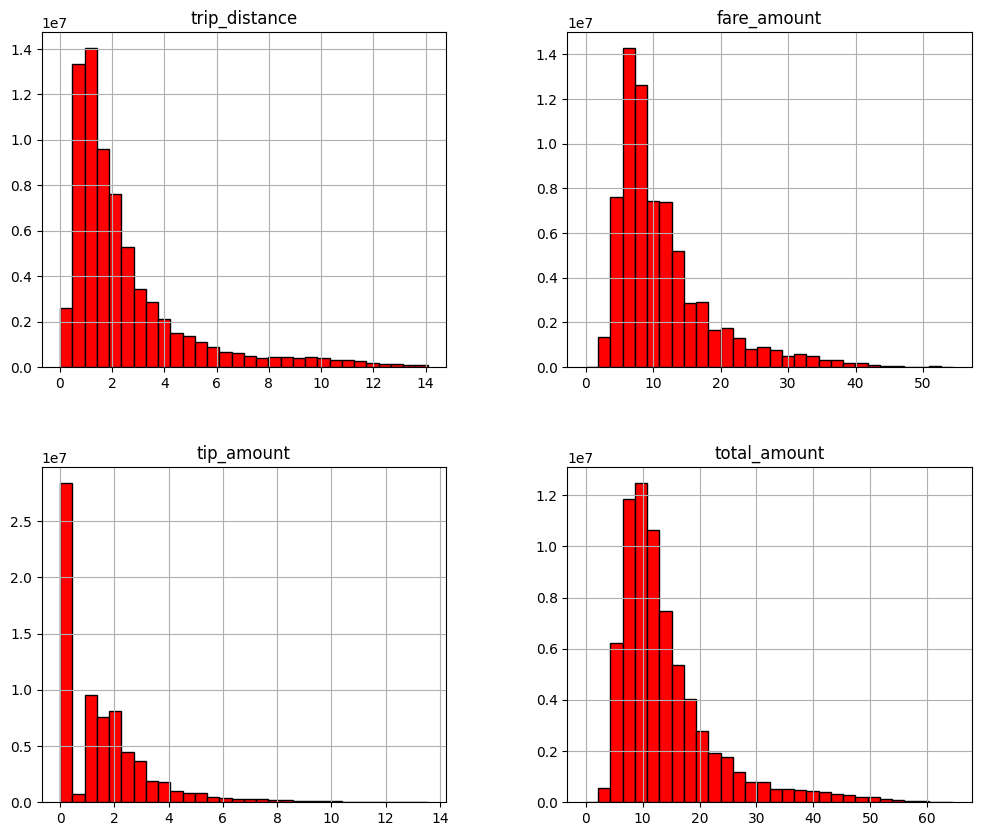

In [130]:
df_clean[
    [
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "total_amount"
    ]
].hist(
    figsize=(12,10),
    bins=30,
    edgecolor="black",
    color="red")
plt.show()

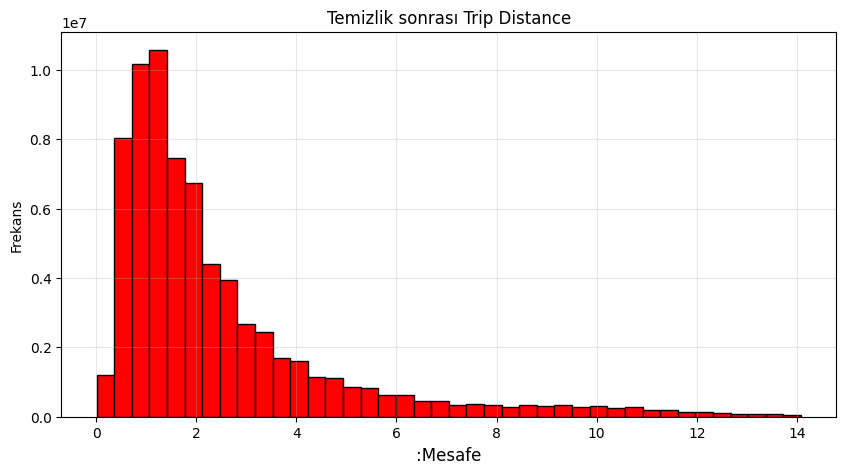

In [131]:
# IQR temizliği sonrası sonrası histogram
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["trip_distance"],
    bins=40,
    edgecolor="black",
    color="red")
plt.xlabel(
    ":Mesafe",
    fontsize=12)
plt.grid(alpha=0.3)
plt.ylabel(
    "Frekans",
    fontsize=10)
plt.title("Temizlik sonrası Trip Distance")
plt.show()

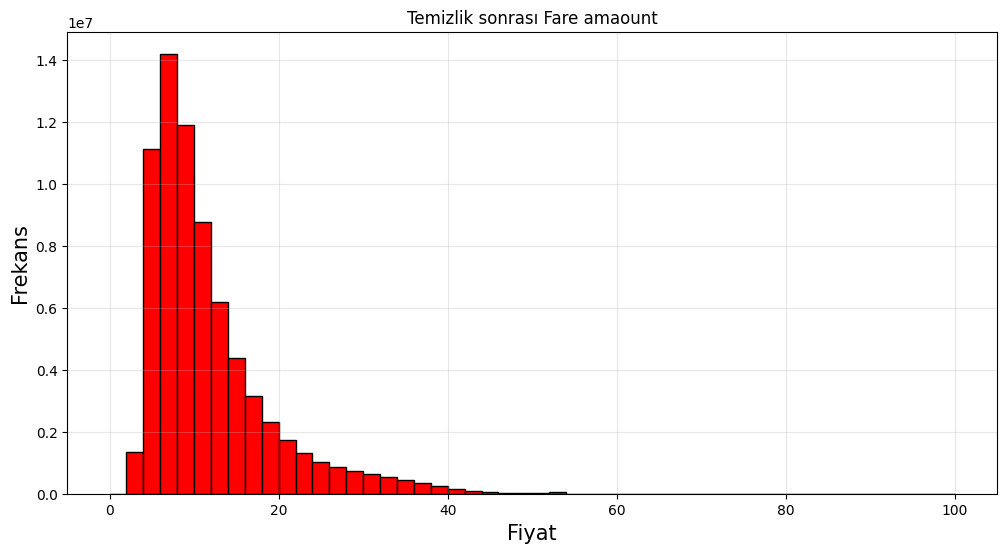

In [147]:
# fare amount histogram
plt.figure(figsize=(12,6))

plt.hist(
    df_clean["fare_amount"],
    bins=50,
    range=(0,100),
    edgecolor="black",
    color="red")

plt.title("Temizlik sonrası Fare amaount")
plt.xlabel(
    "Fiyat",
    fontsize=15)
plt.ylabel(
    "Frekans",
    fontsize=15)
plt.grid(alpha=0.3)
plt.show()

# Z-Score
## Bu yöntem, değerlerin ortalamadan kaç standart sapma uzak olduğunu gösterir.
## z = (x - μ) / σ
## x= veri değeri, μ = ortalama, σ = standart sapma

In [133]:
#alttaki kütüphane formülü otomatik hesaplıyor.
from scipy.stats import zscore

# Z-score hesaplanırken yeni sütunlar eklendiği için ana temiz veri setini bozmamak adına df_clean verisinin kopyasını oluşturdum
df_zscore = df_clean.copy()

# Z-score hesaplanacak sütunlar
zscore_columns = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
]
# Her sütun için z-score değerlerini hesaplanması
for col in zscore_columns:
    df_zscore[col + "_zscore"] = zscore(
        df_zscore[col])

# |z-score| > 3 olan değerleri aykırı değer olarak kontrol ediyorum
for col in zscore_columns:
    outlier_count = (
        df_zscore[col + "_zscore"].abs() > 3
    ).sum()
    print(col, "Z-score outliers:", outlier_count)

trip_distance Z-score outliers: 2186260
fare_amount Z-score outliers: 1565510
tip_amount Z-score outliers: 1533791
total_amount Z-score outliers: 1862780


##  -- Z-score yöntemi IQR yöntemine göre daha fazla outlier tespit etti. Bu yöntem IQR yöntemine göre daha fazla aykırı değer buldu.

### Yıl boyu saatlik trip sayısı

In [134]:
#  saatlik trip sayısını hesaplanması
hourly_data = (
    df_clean[["tpep_pickup_datetime"]]
    .copy()
)
hourly_data["pickup_hour"] = hourly_data["tpep_pickup_datetime"].dt.floor("h")
hourly_data = (
    hourly_data
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count"))
hourly_data = hourly_data.rename(
    columns={"pickup_hour": "tpep_pickup_datetime"})
hourly_data.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,26847
1,2015-01-01 01:00:00,30015
2,2015-01-01 02:00:00,26466
3,2015-01-01 03:00:00,22825
4,2015-01-01 04:00:00,15830


In [135]:
hourly_data.describe()

,tpep_pickup_datetime,trip_count
count,4344,4344.000000
mean,2015-04-01 11:30:00,16491.239180
min,2015-01-01 00:00:00,13.000000
25%,2015-02-15 05:45:00,10944.250000
50%,2015-04-01 11:30:00,18576.000000
75%,2015-05-16 17:15:00,21581.250000
max,2015-06-30 23:00:00,31410.000000
std,NaN,7442.785604


In [136]:
hourly_data.shape

(4344, 2)

In [137]:
# saatlik trip count verisini csv olarak kaydediyorum
hourly_data.to_csv(
    "../outputs/hourly_trip_counts_2015.csv",
    index=False)
print("CSV dosyası kaydedildi")

CSV dosyası kaydedildi
